# Visualisation of tf-idf Article Representations

### import libraries

In [1]:
from wb0configs import configs
from wb0configs.helpers import store_file, load_file, store_xml, load_xml

config = configs.ConfigBase()

In [2]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
import torch
import matplotlib.pylab as plt
import matplotlib as mpl
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

### Dataloader

In [3]:
X_1, X_2, C, E, Y = load_file(config.get_path("task") / "archive" / "conflict_entity_task"  / "data", ftype="pkl")
L = load_file(config.get_path("task") / "conflict_entity_task"  / "label", ftype="pkl")

conflict_id_name = load_file(config.get_path("conflict_retrieval") / "conflict_id_name", ftype="pkl")
entity_id_name = load_file(config.get_path("entity_retrieval") / "entity_id_name", ftype="pkl")

c_id_ent_id_embed = load_file(config.get_path("conflict_embed") / "c_id_ent_id_embed", ftype = "pkl")
ent_id_embed = load_file(config.get_path("task") / "entity_pooled" / "e_id_embed_tfidf", ftype="pkl")
ent_id_sec_embed = load_file(config.get_path("entity_embed") / "e_id_sec_embed_tfidf", ftype = "pkl")

c_e_id = load_file(config.get_path("conflict_retrieval") / "conflict_entity_id", ftype = "pkl")

In [4]:
conflict_id = 36856978
mali_war = [[19127, 5843419], [34593948], [1921]] #c_e_id[36856978] Mali War

## Prepare Data

In [5]:
def get_entity_embed_label(bell_ent_id, ent_id_embed, entity_id_name):
    
    emb = torch.Tensor()
    label_ids = []
    label_bell = []
    label_name = []
    
    for bell_id, bell in enumerate(bell_ent_id):
        for ent_id in bell:
            ent_embed = ent_id_embed[ent_id]
            emb = torch.cat((emb, ent_embed.unsqueeze(0)), 0)
            label_ids.append(ent_id)
            label_bell.append("belligerent " + str(bell_id))
            label_name.append(entity_id_name[ent_id])

    return emb, label_ids, label_bell, label_name, len(label_ids)


def get_entity_sec_embed_label(bell_ent_id, ent_id_sec_embed, entity_id_name):
    
    emb = torch.Tensor()
    label_ids = []
    label_bell = []
    label_name = []
    
    for bell_id, bell in enumerate(bell_ent_id):
        for ent_id in bell:
            for sec_t, sec_emb in ent_id_sec_embed[ent_id].items():
                emb = torch.cat((emb, sec_emb.unsqueeze(0)), 0)
                label_ids.append(str(ent_id) + " – " + str(sec_t))
                label_bell.append("belligerent " + str(bell_id) + str(" section"))
                label_name.append(str(sec_t))

    return emb, label_ids, label_bell, label_name, len(label_ids)


def merge_entity_conflict(*args):
    
    emb  = torch.Tensor()
    label_ids = []
    label_bell = []
    label_name = []
    n_ent_sec = 0
            
    if "entity" in args:
        ent_emb, ent_label_ids, ent_label_bell, ent_label_name, n_ent = get_entity_embed_label(mali_war, ent_id_embed, entity_id_name)
        emb = torch.cat((emb, ent_emb), dim = 0)
        label_ids = label_ids + ent_label_ids
        label_bell = label_bell + ent_label_bell
        label_name = label_name + ent_label_name 
        n_ent_sec = n_ent
        
    if "entity_sec" in args:
        ent_sec_emb, ent_sec_label_ids, ent_sec_label_bell, ent_sec_label_name, n_sec = get_entity_sec_embed_label(mali_war, ent_id_sec_embed, entity_id_name)
        emb = torch.cat((emb, ent_sec_emb), dim = 0)
        label_ids = label_ids + ent_sec_label_ids
        label_bell = label_bell + ent_sec_label_bell
        label_name = label_name + ent_sec_label_name 
        n_ent_sec = n_sec
    
    return emb, label_ids, label_bell, label_name, n_ent_sec
    
    
emb, label_ids, label_bell, label_name, n_ent_sec = merge_entity_conflict("entity", "entity_sec")

label_name[2] = "Azawad Liberation Movement"

## Dimensionality Reduction

In [6]:
def scale_linear_bycolumn(array):
    x_min = np.min(array[:,0])
    x_max = np.max(array[:,0])
    y_min = np.min(array[:,1])
    y_max = np.max(array[:,1])

    array[:,0] = (array[:,0] - x_min) / (x_max - x_min)
    array[:,1] = (array[:,1] - y_min) / (y_max - y_min)
    
    return array


def compute_dim_reduction(embeddings, reduction_method = "tsne"):
    
    if reduction_method == 'tsne':
        tsne = TSNE(n_components=2, verbose=1, perplexity=500, n_iter=300, init='pca')
        result = tsne.fit_transform(embeddings)

    if reduction_method == 'pca':
        pca = PCA(n_components=2)
        pca.fit(embeddings)
        result = pca.transform(embeddings)

    result = scale_linear_bycolumn(result)
    return result


lowdim_embed = compute_dim_reduction(emb, reduction_method = "pca")

## Visualization

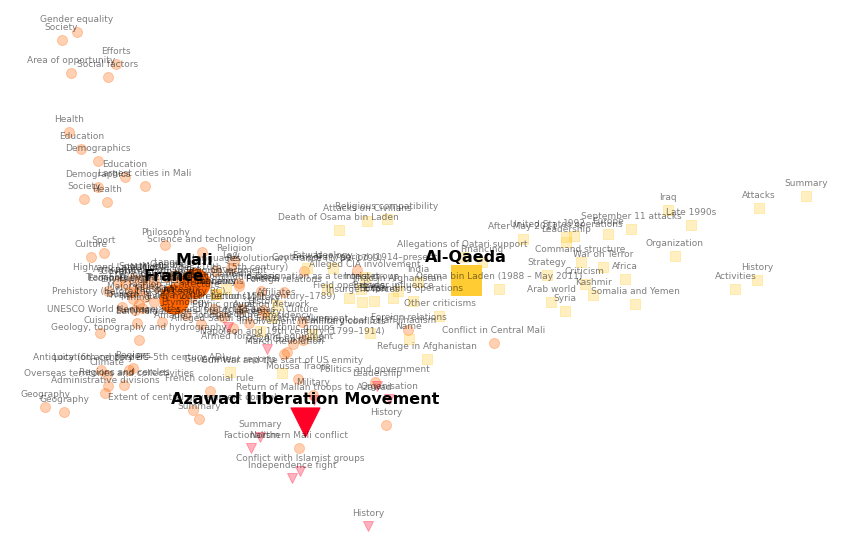

In [7]:
def visualise_dim_reduction(lowdim_embed, label_bell, label_name, n_ent_sec, conflict_id):  
    
    fig, ax = plt.subplots(figsize=(15,10))

    markers = {}
    size = {}
    colors = {}
    alpha = {}
    fontsize = {}
    font_alpha = {}
    font_weight = {}
    y_offset = {}
    
    colormap = cm.get_cmap('RdYlGn', n_ent_sec)
    colormap = colormap(np.linspace(0, 1, 3))
    
    colormap_custom = np.array([[1., 0.        , 0.14901961, 1.        ],
       [1., .8, 0.2, 1.        ],
       [1.        , 0.4, 0.01, 1.        ]])

    for l in label_bell:
        label_type = l.split(" ")[0]

        size[l] = 850
        belligerent_num = int(l.split(" ")[1])
        marker_candidates = ["v","s","o"]
        colors[l] = colormap_custom[belligerent_num - 1]
        markers[l] = marker_candidates[belligerent_num - 1]
        alpha[l] = 1.0
        font_alpha[l] = 1.0
        fontsize[l] = 16
        font_weight[l] = "bold"
        y_offset[l] = 18

        if len(l.split(" ")) == 3:
            alpha[l] = 0.3
            font_alpha[l] = 0.5
            marker_candidates = ["v","s","o"]
            markers[l] = marker_candidates[belligerent_num - 1]
            colors[l] = colormap_custom[belligerent_num - 1]
            size[l] = 100
            fontsize[l] = 9    
            font_weight[l] = "normal"
            y_offset[l] = 10


    for t in range(0, len(label_name)):
        plt.scatter(lowdim_embed[t,0], lowdim_embed[t,1], marker = markers[label_bell[t]], s=size[label_bell[t]], color= colors[label_bell[t]], alpha = alpha[label_bell[t]])
        plt.annotate(str(label_name[t]), xy= (lowdim_embed[t,0], lowdim_embed[t, 1]), textcoords='offset points', xytext=(0.0, y_offset[label_bell[t]]), fontsize = fontsize[label_bell[t]], fontweight=font_weight[label_bell[t]], alpha = font_alpha[label_bell[t]], ha='center')
        plt.axis('off')
        
visualise_dim_reduction(lowdim_embed, label_bell, label_name, n_ent_sec, conflict_id)